In [1]:
# Import required libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


In [2]:
# Load the dataset

df = pd.read_csv("car.csv")

print("Dataset Shape:", df.shape)

df.head()

Dataset Shape: (8128, 12)


,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage(km/ltr/kg),engine,max_power,seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.40,1248.0,74,5.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14,1498.0,103.52,5.0
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.70,1497.0,78,5.0
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.00,1396.0,90,5.0
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.10,1298.0,88.2,5.0


In [3]:
# Display dataset information

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8128 entries, 0 to 8127
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   name                8128 non-null   str    
 1   year                8128 non-null   int64  
 2   selling_price       8128 non-null   int64  
 3   km_driven           8128 non-null   int64  
 4   fuel                8128 non-null   str    
 5   seller_type         8128 non-null   str    
 6   transmission        8128 non-null   str    
 7   owner               8128 non-null   str    
 8   mileage(km/ltr/kg)  7907 non-null   float64
 9   engine              7907 non-null   float64
 10  max_power           7913 non-null   str    
 11  seats               7907 non-null   float64
dtypes: float64(3), int64(3), str(6)
memory usage: 1.2 MB


In [4]:
# Display statistical summary

df.describe()

,year,selling_price,km_driven,mileage(km/ltr/kg),engine,seats
count,8128.000000,8.128000e+03,8.128000e+03,7907.000000,7907.000000,7907.000000
mean,2013.804011,6.382718e+05,6.981951e+04,19.418783,1458.625016,5.416719
std,4.044249,8.062534e+05,5.655055e+04,4.037145,503.916303,0.959588
min,1983.000000,2.999900e+04,1.000000e+00,0.000000,624.000000,2.000000
25%,2011.000000,2.549990e+05,3.500000e+04,16.780000,1197.000000,5.000000
50%,2015.000000,4.500000e+05,6.000000e+04,19.300000,1248.000000,5.000000
75%,2017.000000,6.750000e+05,9.800000e+04,22.320000,1582.000000,5.000000
max,2020.000000,1.000000e+07,2.360457e+06,42.000000,3604.000000,14.000000


In [5]:
# Check missing values

print(df.isnull().sum())

name                    0
year                    0
selling_price           0
km_driven               0
fuel                    0
seller_type             0
transmission            0
owner                   0
mileage(km/ltr/kg)    221
engine                221
max_power             215
seats                 221
dtype: int64


In [6]:
# Convert numerical columns to numeric format

numerical_columns = [
    'mileage(km/ltr/kg)',
    'engine',
    'max_power',
    'seats'
]

for column in numerical_columns:
    df[column] = pd.to_numeric(df[column], errors='coerce')

# Fill missing values using median
for column in numerical_columns:
    df[column] = df[column].fillna(df[column].median())

print("Missing values after cleaning:")
print(df.isnull().sum())

Missing values after cleaning:
name                  0
year                  0
selling_price         0
km_driven             0
fuel                  0
seller_type           0
transmission          0
owner                 0
mileage(km/ltr/kg)    0
engine                0
max_power             0
seats                 0
dtype: int64


In [7]:
# Check duplicate rows

print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 1202


In [8]:
# Remove duplicate rows

df = df.drop_duplicates()

print("Dataset shape after removing duplicates:", df.shape)

Dataset shape after removing duplicates: (6926, 12)


In [9]:
# Create car age

current_year = 2026
df['car_age'] = current_year - df['year']

# Extract car brand from car name
df['brand'] = df['name'].str.split().str[0]

df[['name', 'year', 'car_age', 'brand']].head()

,name,year,car_age,brand
0,Maruti Swift Dzire VDI,2014,12,Maruti
1,Skoda Rapid 1.5 TDI Ambition,2014,12,Skoda
2,Honda City 2017-2020 EXi,2006,20,Honda
3,Hyundai i20 Sportz Diesel,2010,16,Hyundai
4,Maruti Swift VXI BSIII,2007,19,Maruti


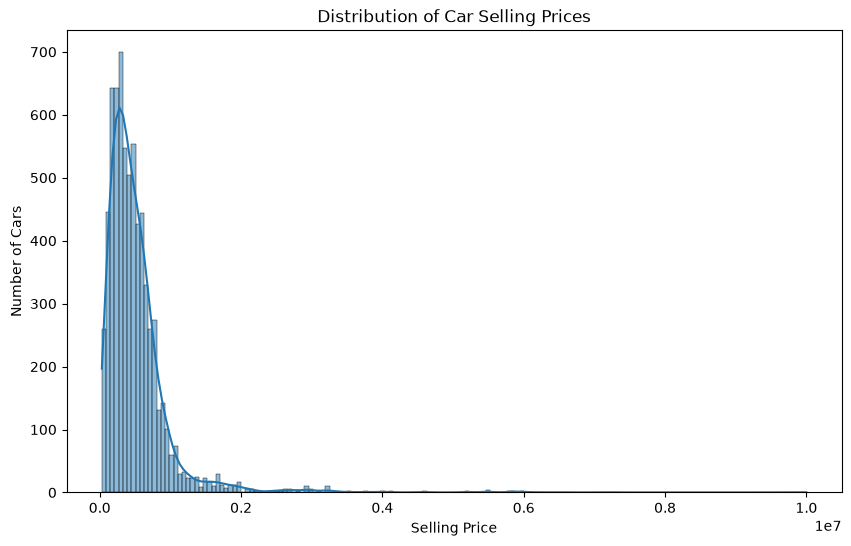

In [10]:
## Exploratory Data Analysis
plt.figure(figsize=(10, 6))

sns.histplot(df['selling_price'], kde=True)

plt.title('Distribution of Car Selling Prices')
plt.xlabel('Selling Price')
plt.ylabel('Number of Cars')
plt.show()

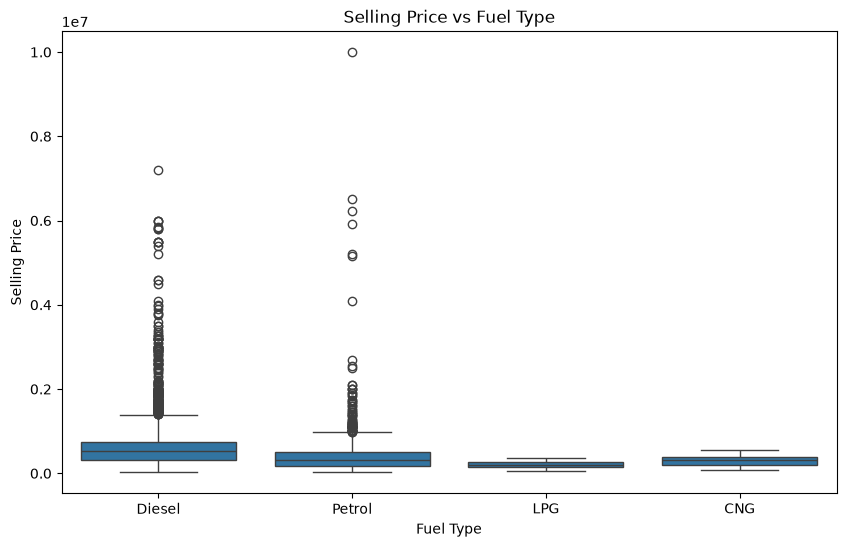

In [11]:
plt.figure(figsize=(10, 6))

sns.boxplot(data=df, x='fuel', y='selling_price')

plt.title('Selling Price vs Fuel Type')
plt.xlabel('Fuel Type')
plt.ylabel('Selling Price')
plt.show()

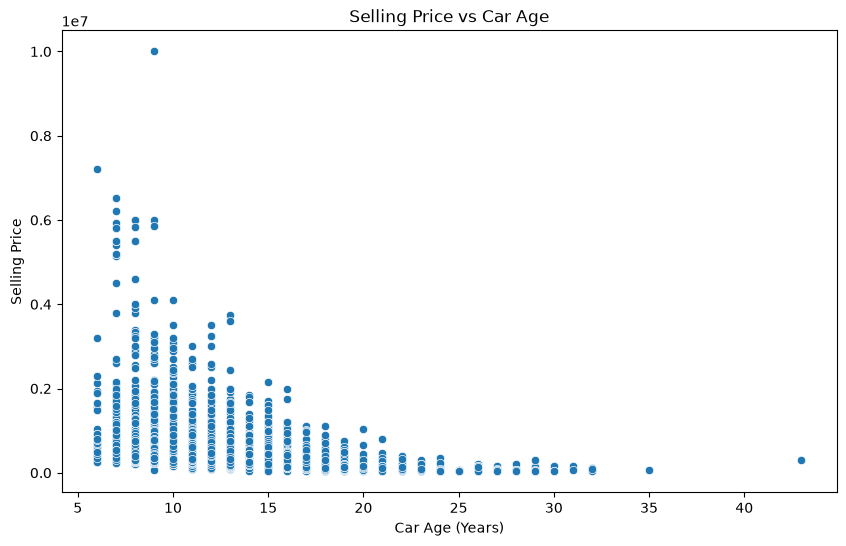

In [12]:
plt.figure(figsize=(10, 6))

sns.scatterplot(data=df, x='car_age', y='selling_price')

plt.title('Selling Price vs Car Age')
plt.xlabel('Car Age (Years)')
plt.ylabel('Selling Price')
plt.show()

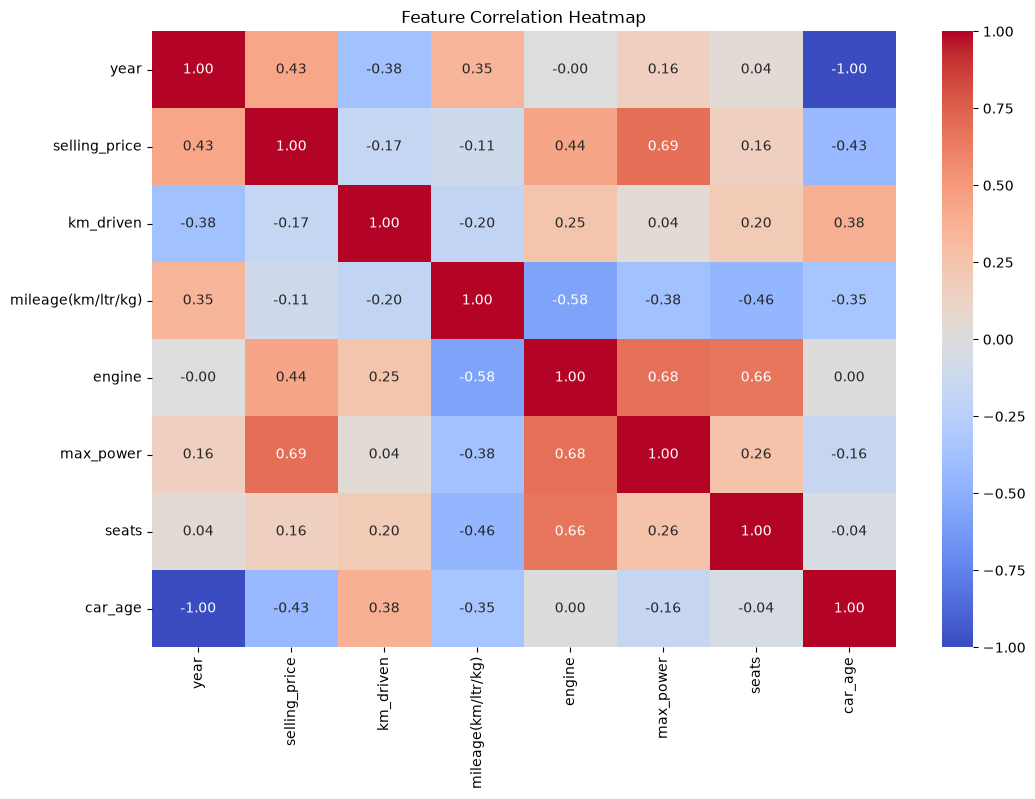

In [13]:
## Feature Correlation Analysis
# # Select numerical features

numerical_df = df.select_dtypes(include=['number'])

# Calculate correlation matrix
correlation_matrix = numerical_df.corr()

# Plot heatmap
plt.figure(figsize=(12, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Feature Correlation Heatmap')
plt.show()

In [14]:
##Data Preparation for Machine Learning
# Define features and target

X = df.drop(columns=['selling_price'])
y = df['selling_price']

categorical_features = [
    'fuel',
    'seller_type',
    'transmission',
    'owner',
    'brand'
]

numerical_features = [
    'year',
    'km_driven',
    'mileage(km/ltr/kg)',
    'engine',
    'max_power',
    'seats',
    'car_age'
]

In [15]:
# Create preprocessing pipeline

preprocessor = ColumnTransformer(
    transformers=[
        (
            'categorical',
            OneHotEncoder(handle_unknown='ignore'),
            categorical_features
        ),
        (
            'numerical',
            'passthrough',
            numerical_features
        )
    ]
)

print("Preprocessing pipeline created successfully.")

Preprocessing pipeline created successfully.


In [16]:
##  Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (5540, 13)
Testing data: (1386, 13)


In [17]:
##  Linear Regression
linear_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

linear_model.fit(X_train, y_train)

linear_predictions = linear_model.predict(X_test)

print("Linear Regression model trained successfully.")

Linear Regression model trained successfully.


In [18]:
linear_mae = mean_absolute_error(y_test, linear_predictions)
linear_rmse = np.sqrt(mean_squared_error(y_test, linear_predictions))
linear_r2 = r2_score(y_test, linear_predictions)

print("Linear Regression Performance")
print("-----------------------------")
print("MAE :", linear_mae)
print("RMSE:", linear_rmse)
print("R²  :", linear_r2)

Linear Regression Performance
-----------------------------
MAE : 167852.03919906286
RMSE: 298211.2215060971
R²  : 0.5945227406589642


In [19]:
##  Random Forest Regressor
rf_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(
        n_estimators=100,
        random_state=42
    ))
])

rf_model.fit(X_train, y_train)

rf_predictions = rf_model.predict(X_test)

print("Random Forest Regressor model trained successfully.")

Random Forest Regressor model trained successfully.


In [20]:
rf_mae = mean_absolute_error(y_test, rf_predictions)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_predictions))
rf_r2 = r2_score(y_test, rf_predictions)

print("Random Forest Regressor Performance")
print("-----------------------------------")
print("MAE :", rf_mae)
print("RMSE:", rf_rmse)
print("R²  :", rf_r2)

Random Forest Regressor Performance
-----------------------------------
MAE : 73729.03610547082
RMSE: 130410.25168589399
R²  : 0.922457106029476


In [21]:
##  Model Performance Comparison
model_comparison = pd.DataFrame({
    'Model': [
        'Linear Regression',
        'Random Forest Regressor'
    ],
    'MAE': [
        linear_mae,
        rf_mae
    ],
    'RMSE': [
        linear_rmse,
        rf_rmse
    ],
    'R² Score': [
        linear_r2,
        rf_r2
    ]
})

model_comparison

,Model,MAE,RMSE,R² Score
0,Linear Regression,167852.039199,298211.221506,0.594523
1,Random Forest Regressor,73729.036105,130410.251686,0.922457


In [22]:
if rf_r2 > linear_r2:
    best_model = "Random Forest Regressor"
else:
    best_model = "Linear Regression"

print("Best Performing Model:", best_model)

Best Performing Model: Random Forest Regressor


In [23]:
## Feature Importance
rf_preprocessor = rf_model.named_steps['preprocessor']

feature_names = rf_preprocessor.get_feature_names_out()

importances = rf_model.named_steps['model'].feature_importances_

feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
})

feature_importance_df = feature_importance_df.sort_values(
    by='Importance',
    ascending=False
)

feature_importance_df.head(10)

,Feature,Importance
48,numerical__max_power,0.599355
50,numerical__car_age,0.120763
44,numerical__year,0.110143
45,numerical__km_driven,0.044684
46,numerical__mileage(km/ltr/kg),0.039806
47,numerical__engine,0.023085
49,numerical__seats,0.008542
33,categorical__brand_Mercedes-Benz,0.005788
41,categorical__brand_Toyota,0.005529
40,categorical__brand_Tata,0.004117


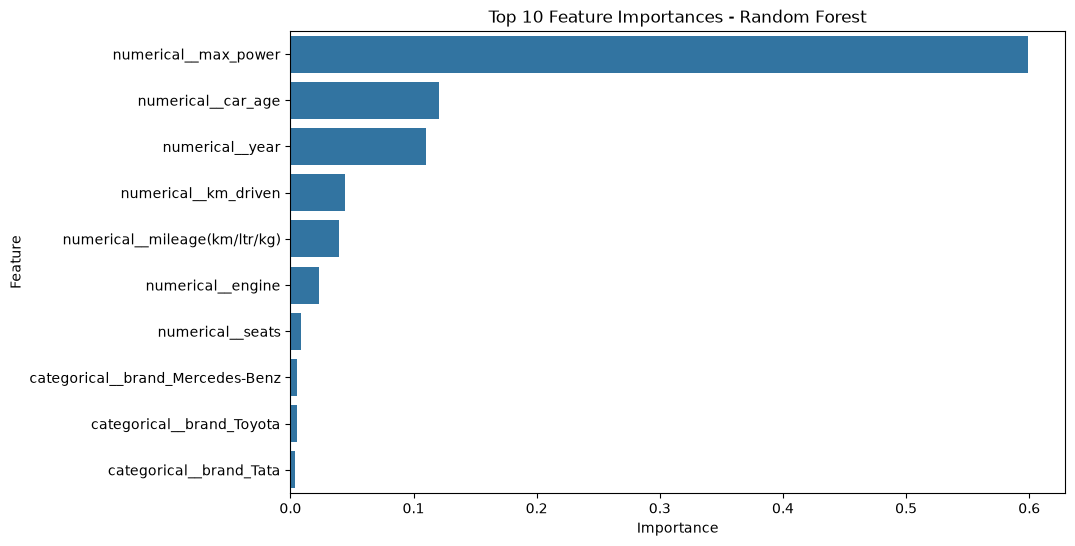

In [24]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=feature_importance_df.head(10),
    x='Importance',
    y='Feature'
)

plt.title('Top 10 Feature Importances - Random Forest')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

##  Conclusion

The Car Price Prediction project was successfully implemented using machine learning techniques.

Two regression models were trained and evaluated:

1. Linear Regression
2. Random Forest Regressor

The models were evaluated using Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and R² Score.

Based on the evaluation results, the **Random Forest Regressor** achieved the best overall performance and was selected as the final model.

Feature importance analysis was performed using the Random Forest model to identify the most influential features for predicting used-car selling prices.

This project demonstrates a complete machine learning workflow, including data cleaning, feature engineering, exploratory data analysis, categorical encoding, model training, evaluation, model comparison, and feature importance analysis.